# ***UnSupervised Models + SVM***

In [ ]:
# Library
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder , LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score ,confusion_matrix, roc_curve, auc , silhouette_score
from sklearn.model_selection import RandomizedSearchCV , GridSearchCV
from sklearn.inspection import DecisionBoundaryDisplay
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage , fcluster
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.impute import SimpleImputer
from sklearn.datasets import make_blobs

In [ ]:
# conect drive file
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# *Part A – Supervised Model: SVM*

> ***Data Preprocessing***

In [ ]:
# import breast cancer wisconsin diagnostic
path ='/content/drive/MyDrive/bc.csv'
bcwd = pd.read_csv(path)
bcwd

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [ ]:
# check missing value
bcwd.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
# dropp unnecessary column Unnamed: 32 & id
bcwd.drop('id', axis=1, inplace=True)
bcwd.drop('Unnamed: 32', axis=1, inplace=True)
bcwd

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
bcwd['diagnosis'].value_counts() # print diagnosis column

,count
diagnosis,
B,357
M,212


In [ ]:
# Encode diagnosis (label encoding)
bcwd['diagnosis'] = bcwd['diagnosis'].map({'M': 1, 'B': 0})
x_bcwd = bcwd.drop('diagnosis', axis=1) #Separate features (X) and target (y)
y_bcwd = bcwd['diagnosis']
bcwd

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
# (( Split the data into training and testing sets "70% train, 30% test" ))

X_bcwd_train, X_bcwd_test, y_bcwd_train, y_bcwd_test = train_test_split(x_bcwd, y_bcwd, test_size=0.3, random_state=42)

X_bcwd_train ,y_bcwd_train

(     radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
 149       13.740         17.91           88.12      585.0          0.07944   
 124       13.370         16.39           86.10      553.5          0.07115   
 421       14.690         13.98           98.22      656.1          0.10310   
 195       12.910         16.33           82.53      516.4          0.07941   
 545       13.620         23.23           87.19      573.2          0.09246   
 ..           ...           ...             ...        ...              ...   
 71         8.888         14.64           58.79      244.0          0.09783   
 106       11.640         18.33           75.17      412.5          0.11420   
 270       14.290         16.82           90.30      632.6          0.06429   
 435       13.980         19.62           91.12      599.5          0.10600   
 102       12.180         20.52           77.22      458.7          0.08013   
 
      compactness_mean  concavity_mean  concave po

In [ ]:
# Standardize numerical features
scaler = StandardScaler()
X_bcwd_train_scaled = scaler.fit_transform(X_bcwd_train)
X_bcwd_test_scaled = scaler.transform(X_bcwd_test)



> ***BC Data Models Building & Evaluation then Visualization***



```
#SVM_linear
```

In [ ]:
svm_linear_bcwd = SVC(kernel='linear', C=1, probability=True)
svm_linear_bcwd.fit(X_bcwd_train_scaled, y_bcwd_train)

SVC(C=1, kernel='linear', probability=True)

In [ ]:
#  Evaluate (Making predictions on the test set)
y_bcwd_pred_linear = svm_linear_bcwd.predict(X_bcwd_test_scaled)
# ((predictions)) vs (actual values)
print("Predicted values:", y_bcwd_pred_linear)
print()
print("Actual values:", y_bcwd_test.values)

Predicted values: [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 0 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 1 1 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]

Actual values: [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]


In [ ]:
# Compute metrics Linear SVM on Adult dataset
SVM_linear_accuracy = accuracy_score(y_bcwd_test, y_bcwd_pred_linear)
SVM_linear_precision = precision_score(y_bcwd_test, y_bcwd_pred_linear)
SVM_linear_recall = recall_score(y_bcwd_test, y_bcwd_pred_linear)
SVM_linear_f1 = f1_score(y_bcwd_test, y_bcwd_pred_linear)
SVM_linear_auc = roc_auc_score(y_bcwd_test, svm_linear_bcwd.decision_function(X_bcwd_test_scaled))

# Print the metrics
print("Accuracy:", SVM_linear_accuracy)
print("Precision:", SVM_linear_precision)
print("Recall:", SVM_linear_recall)
print("F1 Score:", SVM_linear_f1)
print("AUC:", SVM_linear_auc)

Accuracy: 0.9766081871345029
Precision: 0.9682539682539683
Recall: 0.9682539682539683
F1 Score: 0.9682539682539683
AUC: 0.9964726631393297


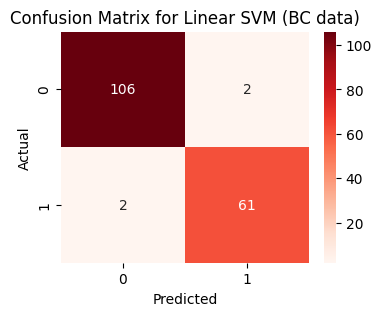

In [ ]:
# confusion matrices for Linear SVM
LinearSVM_cm = confusion_matrix(y_bcwd_test, y_bcwd_pred_linear)
plt.figure(figsize=(4, 3))
sns.heatmap(LinearSVM_cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Linear SVM (BC data)')
plt.show()

```
#SVM_Non-linear
```

In [ ]:
svm_rbf_bcwd = SVC(kernel='rbf', C=1, gamma='scale', probability=True)
svm_rbf_bcwd.fit(X_bcwd_train_scaled, y_bcwd_train)

SVC(C=1, probability=True)

In [ ]:
#  Evaluate (Making predictions on the test set)
y_bcwd_pred_Nlinear = svm_rbf_bcwd.predict(X_bcwd_test_scaled)
# ((predictions)) vs (actual values)
print("Predicted values:", y_bcwd_pred_Nlinear)
print()
print("Actual values:", y_bcwd_test.values)

Predicted values: [0 1 1 0 0 1 1 1 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 0 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]

Actual values: [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]


In [ ]:
# Compute metrics Non-Linear SVM on Adult dataset
SVM_Nlinear_accuracy = accuracy_score(y_bcwd_test, y_bcwd_pred_Nlinear)
SVM_Nlinear_precision = precision_score(y_bcwd_test, y_bcwd_pred_Nlinear)
SVM_Nlinear_recall = recall_score(y_bcwd_test, y_bcwd_pred_Nlinear)
SVM_Nlinear_f1 = f1_score(y_bcwd_test, y_bcwd_pred_Nlinear)
SVM_Nlinear_auc = roc_auc_score(y_bcwd_test, svm_rbf_bcwd.decision_function(X_bcwd_test_scaled))

# Print the metrics
print("Accuracy:", SVM_Nlinear_accuracy)
print("Precision:", SVM_Nlinear_precision)
print("Recall:", SVM_Nlinear_recall)
print("F1 Score:", SVM_Nlinear_f1)
print("AUC:", SVM_Nlinear_auc)

Accuracy: 0.9766081871345029
Precision: 0.9682539682539683
Recall: 0.9682539682539683
F1 Score: 0.9682539682539683
AUC: 0.9966196355085244


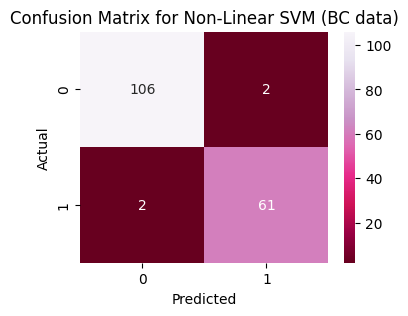

In [ ]:
# confusion matrices for Linear SVM
NLinearSVM_cm = confusion_matrix(y_bcwd_test, y_bcwd_pred_Nlinear)
plt.figure(figsize=(4, 3))
sns.heatmap(NLinearSVM_cm, annot=True, fmt='d', cmap='PuRd_r')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Non-Linear SVM (BC data)')
plt.show()

In [ ]:
# Get the predicted probabilities for the positive class for each model
y_bcwd_pred_prob_linear = svm_linear_bcwd.predict_proba(X_bcwd_test_scaled)[:,1]
y_bcwd_pred_prob_Nlinear = svm_rbf_bcwd.predict_proba(X_bcwd_test_scaled)[:,1]

# Calculate the False Positive Rate, True Positive Rate, and thresholds
fpr_linear, tpr_linear, _ = roc_curve(y_bcwd_test, y_bcwd_pred_prob_linear)
fpr_Nlinear, tpr_Nlinear, _ = roc_curve(y_bcwd_test, y_bcwd_pred_prob_Nlinear)

# Calculate the Area Under the ROC Curve (AUC)
roc_auc_linear_bcwd = auc(fpr_linear, tpr_linear)
roc_auc_Nlinear_bcwd = auc(fpr_Nlinear, tpr_Nlinear)

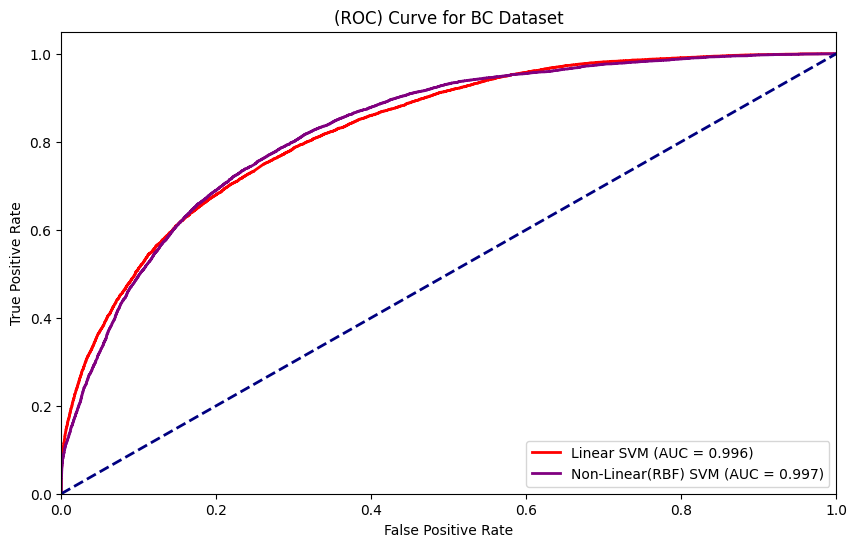

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(fpr_linear, tpr_linear, color='red', lw=2, label='Linear SVM (AUC = %0.3f)' % roc_auc_linear_bcwd)
plt.plot(fpr_Nlinear, tpr_Nlinear, color='purple', lw=2, label='Non-Linear(RBF) SVM (AUC = %0.3f)' % roc_auc_Nlinear_bcwd)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('(ROC) Curve for BC Dataset')
plt.legend(loc="lower right")
plt.show()

# *Part B – Unsupervised Models: K-Means & Hierarchical Clustering*

> ***BC Data Preprocessing***

In [ ]:
# import breast cancer wisconsin diagnostic
path ='/content/drive/MyDrive/bc.csv'
bcwd2 = pd.read_csv(path)
bcwd2

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [ ]:
# check missing value
bcwd2.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
# dropp unnecessary column Unnamed: 32 & id
bcwd2.drop('id', axis=1, inplace=True)
bcwd2.drop('Unnamed: 32', axis=1, inplace=True)
bcwd2

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
# Encode diagnosis (label encoding)
bcwd2['diagnosis'] = bcwd2['diagnosis'].map({'M': 1, 'B': 0})
x_bcwd2 = bcwd2.drop('diagnosis', axis=1) #Separate features (X) and target (y)
y_bcwd2 = bcwd2['diagnosis']
bcwd2

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
# Standardize numerical features
scaler = StandardScaler()
X_bcwd2_train_scaled = scaler.fit_transform(x_bcwd2)
X_bcwd2_test_scaled = scaler.transform(x_bcwd2)

> ***BC Data Models Building & Evaluation then Visualization***

```
# K-means
```

In [ ]:
# K-means
kmeans_bcwd2 = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_bcwd2.fit(X_bcwd2_train_scaled)

KMeans(n_clusters=2, n_init=10, random_state=42)

In [ ]:
# Compute a Silhouette Score
clusters_kmeans_pred_bcwd2 = kmeans_bcwd2.predict(X_bcwd2_train_scaled)
kmeans_silhouette_bcwd2 = silhouette_score(X_bcwd2_train_scaled, clusters_kmeans_pred_bcwd2)
print(f"K-Means Silhouette Score (BC): {kmeans_silhouette_bcwd2:.4f}")

K-Means Silhouette Score (BC): 0.3434


In [ ]:
# Compare clusters to true labels with a simple table
table_bcwd2 = pd.crosstab(y_bcwd2, clusters_kmeans_pred_bcwd2, rownames=['True Labels'], colnames=['K-Means Clusters'])
print("\nK-Means Cluster vs. True Labels (BC):")
print(table_bcwd2)


K-Means Cluster vs. True Labels (BC):
K-Means Clusters    0    1
True Labels               
0                 339   18
1                  36  176


```
# Hierarchical Clustering
```

In [ ]:
# Sampling the data for Hierarchical Clustering
sample_size = 1000
np.random.seed(42)
sample_indices = np.random.choice(X_bcwd2_train_scaled.shape[0], size=sample_size)
X_sample_bcwd2 = X_bcwd2_train_scaled[sample_indices]
y_sample_bcwd2 = y_bcwd2.iloc[sample_indices]

In [ ]:
# Linkage methods: single, complete, average
hierarchical_results_bcwd = {}

for method in linkage_methods:
    # Apply AgglomerativeClustering on full data (BCWD is small enough)
    hierarchical_bcwd2 = AgglomerativeClustering(n_clusters=2, linkage=method)
    clusters_hierarchical_pred_bcwd2 = hierarchical_bcwd2.fit_predict(X_bcwd2_train_scaled)

    # Evaluate on full data
    silhouette_avg = silhouette_score(X_bcwd2_train_scaled, clusters_hierarchical_pred_bcwd2)
    hierarchical_results_bcwd[method] = silhouette_avg

    # Store the best result for later visualization
    if method == 'complete': # Use complete linkage for the main visualization
        best_agg_labels_bcwd = clusters_hierarchical_pred_bcwd2
        best_hierarchical_method_bcwd = method

print("\nAll Hierarchical Clustering Silhouette Scores (BCWD):")
for method, score in hierarchical_results_bcwd.items():
    print(f"  {method}: {score:.4f}")


All Hierarchical Clustering Silhouette Scores (BCWD):
  single: 0.6607
  complete: 0.6607
  average: 0.6340


In [ ]:
# Compare clusters to true labels (Best Method)
agg_crosstab_bcwd = pd.crosstab(y_bcwd2, best_agg_labels_bcwd, rownames=['True Labels'], colnames=['Hierarchical Clusters'])
print("\nHierarchical Cluster vs. True Labels (BCWD):")
print(agg_crosstab_bcwd)


Hierarchical Cluster vs. True Labels (BCWD):
Hierarchical Clusters    0  1
True Labels                  
0                      357  0
1                      210  2



--- (PCA to 2D) for BCWD Dataset ---


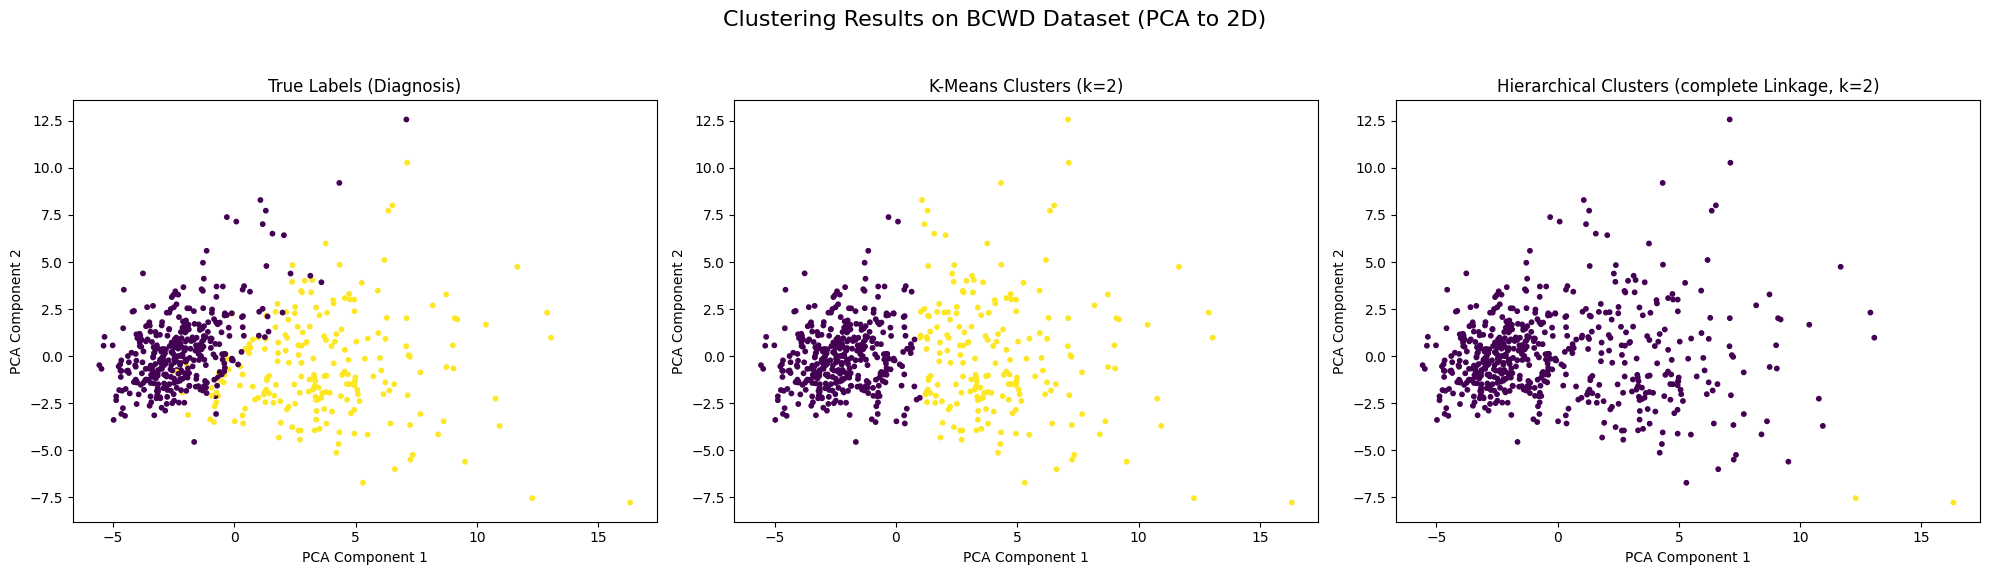

In [ ]:
# PCA to 2D
print("\n--- (PCA to 2D) for BCWD Dataset ---")

# Reduce dimensionality to 2D using PCA
pca_bcwd = PCA(n_components=2)
X_pca_bcwd = pca_bcwd.fit_transform(X_bcwd2_train_scaled)

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Clustering Results on BCWD Dataset (PCA to 2D)', fontsize=16)

# Plot 1: True Labels
scatter1 = axes[0].scatter(X_pca_bcwd[:, 0], X_pca_bcwd[:, 1], c=y_bcwd2, cmap='viridis', s=10)
axes[0].set_title('True Labels (Diagnosis)')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')

# Plot 2: K-Means Clusters
scatter2 = axes[1].scatter(X_pca_bcwd[:, 0], X_pca_bcwd[:, 1], c=clusters_kmeans_pred_bcwd2, cmap='viridis', s=10)
axes[1].set_title('K-Means Clusters (k=2)')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')

# Plot 3: Hierarchical Clusters (Best Method)
scatter3 = axes[2].scatter(X_pca_bcwd[:, 0], X_pca_bcwd[:, 1], c=best_agg_labels_bcwd, cmap='viridis', s=10)
axes[2].set_title(f'Hierarchical Clusters ({best_hierarchical_method_bcwd} Linkage, k=2)')
axes[2].set_xlabel('PCA Component 1')
axes[2].set_ylabel('PCA Component 2')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])


--- Dendrogram for Hierarchical Clustering (BCWD Dataset) ---


Text(0, 0.5, 'Distance')

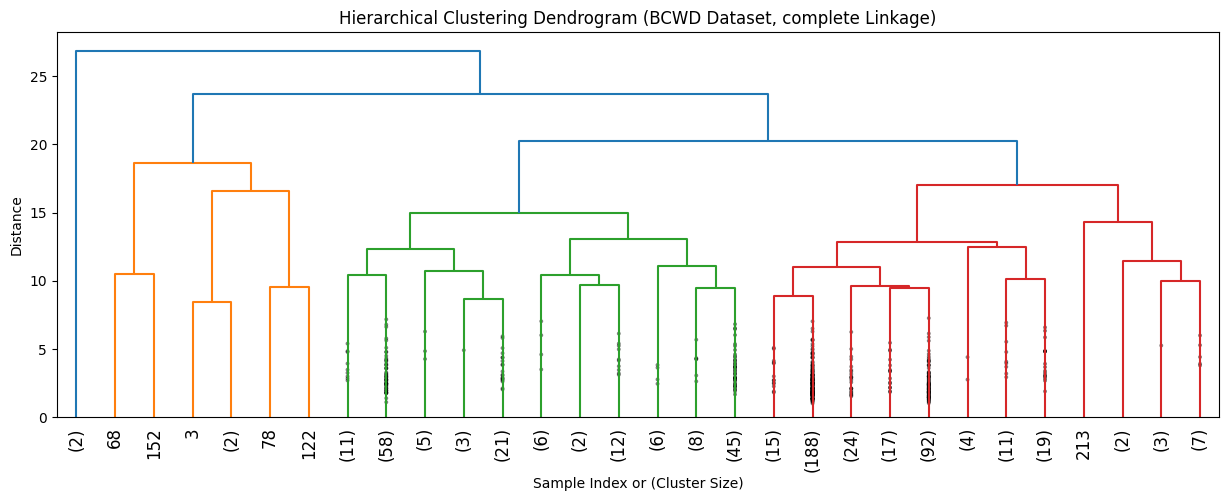

In [ ]:
# --- Dendrogram for Hierarchical Clustering ---
print("\n--- Dendrogram for Hierarchical Clustering (BCWD Dataset) ---")

# Perform linkage on the full data
linked_bcwd = linkage(X_bcwd2_train_scaled, method=best_hierarchical_method_bcwd)

# Plot the dendrogram
plt.figure(figsize=(15,5))
dendrogram(
    linked_bcwd,
    orientation='top',
    truncate_mode='lastp',
    p=30,
    show_leaf_counts=True,
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,
)
plt.title(f'Hierarchical Clustering Dendrogram (BCWD Dataset, {best_hierarchical_method_bcwd} Linkage)')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')